# HR Employee Attrition Analysis
## Data Cleaning and Exploratory Data Analysis

## 1. Import Libraries and Load Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [9]:
file_path = "../data/HR-Employee-Attrition.csv"
df = pd.read_csv(file_path)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [10]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (1470, 35)

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


The dataset contains 1,470 employee records and 35 columns. Each row represents one employee.

## 2. Data Structure and Quality Check

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [15]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values[missing_values > 0])

Missing values by column:
Series([], dtype: int64)


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
print("Unique Employee IDs:", df["EmployeeNumber"].nunique())
print("Total Rows:", len(df))

Unique Employee IDs: 1470
Total Rows: 1470


In [18]:
attrition_summary = df["Attrition"].value_counts()

print(attrition_summary)

print("\nAttrition Percentage:")
print((df["Attrition"].value_counts(normalize=True) * 100).round(2))

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


### Data Quality Summary

- The dataset has no missing values.
- There are no duplicate employee records.
- EmployeeNumber is unique for every employee.
- Attrition is the target variable.
- 237 employees left the company, representing an attrition rate of 16.12%.

## 3. Understand Column Values

In [19]:
unique_counts = df.nunique().sort_values()
print(unique_counts)

Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [20]:
constant_columns = [
    column for column in df.columns
    if df[column].nunique() == 1
]

print("Constant columns:", constant_columns)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [21]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Attrition ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

--- Department ---
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

--- EducationField ---
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

--- Gender ---
Gender
Male      882
Female    588
Name: count, dtype: int64

--- JobRole ---
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int

In [22]:
rating_columns = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "PerformanceRating",
    "StockOptionLevel"
]

for column in rating_columns:
    print(f"\n--- {column} ---")
    print(sorted(df[column].unique()))


--- Education ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

--- EnvironmentSatisfaction ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- JobInvolvement ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- JobLevel ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

--- JobSatisfaction ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- RelationshipSatisfaction ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- WorkLifeBalance ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- PerformanceRating ---
[np.int64(3), np.int64(4)]

--- StockOptionLevel ---
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### Initial Cleaning Decisions

- `EmployeeCount`, `Over18`, and `StandardHours` are constant columns and will be removed.
- `EmployeeNumber` is a unique identifier and will not be used in visual analysis.
- Rating and level fields are stored as integers but will be treated as ordered categories where appropriate.

In [23]:
for column in ["Attrition", "OverTime", "Department"]:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())
    print("\nPercentage:")
    print((df[column].value_counts(normalize=True) * 100).round(2))


--- Attrition ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

--- OverTime ---
OverTime
No     1054
Yes     416
Name: count, dtype: int64

Percentage:
OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64

--- Department ---
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Percentage:
Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64


## 4. Create Clean Analysis Dataset

In [24]:
columns_to_drop = [
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df_clean = df.drop(columns=columns_to_drop).copy()

print("Original dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)


Original dataset shape: (1470, 35)
Clean dataset shape: (1470, 32)


In [25]:
df_clean["AttritionFlag"] = df_clean["Attrition"].map({
    "No": 0,
    "Yes": 1
})

df_clean[["Attrition", "AttritionFlag"]].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [26]:
print("Final clean dataset shape:", df_clean.shape)
print("\nAttritionFlag values:")
print(df_clean["AttritionFlag"].value_counts())

Final clean dataset shape: (1470, 33)

AttritionFlag values:
AttritionFlag
0    1233
1     237
Name: count, dtype: int64


A cleaned analysis dataset was created with 32 original useful columns and one AttritionFlag column. The original dataset remains unchanged.

## 5. Attrition Rate Analysis

In [27]:
overall_attrition_rate = df_clean["AttritionFlag"].mean() * 100

print(f"Overall Attrition Rate: {overall_attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [45]:
def calculate_attrition_rate(data, group_column):
    summary = (
        data.groupby(group_column, observed=False)
        .agg(
            Total_Employees=("AttritionFlag", "count"),
            Attrition_Count=("AttritionFlag", "sum"),
            Attrition_Rate=("AttritionFlag", "mean")
        )
    )
    
    summary["Attrition_Rate"] = (summary["Attrition_Rate"] * 100).round(2)
    
    return summary.sort_values("Attrition_Rate", ascending=False)

In [34]:
department_attrition = calculate_attrition_rate(df_clean, "Department")

department_attrition

,Total_Employees,Attrition_Count,Attrition_Rate
Department,,,
Sales,446,92,20.63
Human Resources,63,12,19.05
Research & Development,961,133,13.84


In [35]:
overtime_attrition = calculate_attrition_rate(df_clean, "OverTime")

overtime_attrition

,Total_Employees,Attrition_Count,Attrition_Rate
OverTime,,,
Yes,416,127,30.53
No,1054,110,10.44


### Initial Insights

- Sales has the highest department attrition rate at 20.63%.
- Employees working overtime have an attrition rate of 30.53%, compared with 10.44% for employees not working overtime.
- Overtime is a key attrition factor to investigate further.
- Results show associations and should not be interpreted as proof of causation.

## 6. Visual Analysis

In [38]:
sns.set_theme(style="whitegrid", palette="deep")

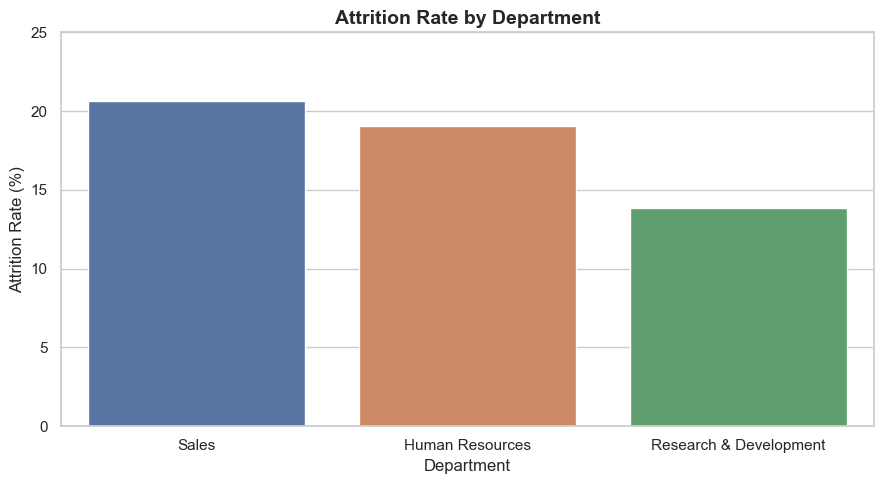

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=department_attrition.reset_index(),
    x="Department",
    y="Attrition_Rate",
    hue="Department",
    legend=False
)

plt.title("Attrition Rate by Department", fontsize=14, fontweight="bold")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 25)

plt.tight_layout()
plt.savefig("../visuals/attrition_by_department.png", dpi=300)
plt.show()

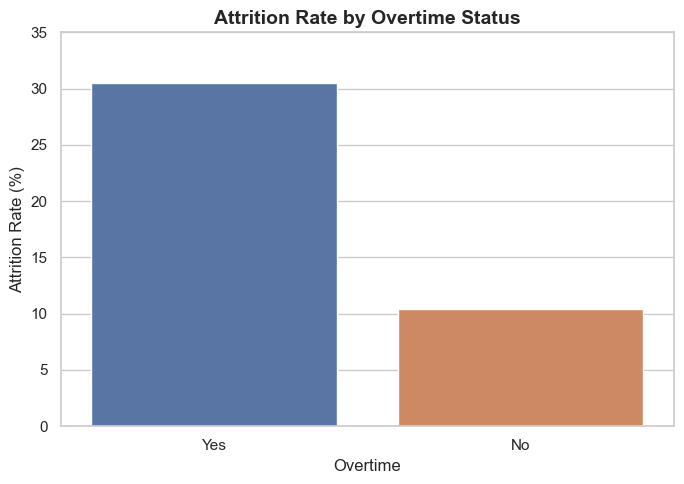

In [41]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=overtime_attrition.reset_index(),
    x="OverTime",
    y="Attrition_Rate",
    hue="OverTime",
    legend=False
)

plt.title("Attrition Rate by Overtime Status", fontsize=14, fontweight="bold")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 35)

plt.tight_layout()
plt.savefig("../visuals/attrition_by_overtime.png", dpi=300)
plt.show()

In [42]:
jobrole_attrition = calculate_attrition_rate(df_clean, "JobRole")

jobrole_attrition

,Total_Employees,Attrition_Count,Attrition_Rate
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50


In [43]:
age_bins = [17, 25, 35, 45, 55, 65]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=age_bins,
    labels=age_labels
)

print(df_clean[["Age", "AgeGroup"]].head(10))

   Age AgeGroup
0   41    36-45
1   49    46-55
2   37    36-45
3   33    26-35
4   27    26-35
5   32    26-35
6   59    56-65
7   30    26-35
8   38    36-45
9   36    36-45


In [46]:
agegroup_attrition = calculate_attrition_rate(df_clean, "AgeGroup")

agegroup_attrition

,Total_Employees,Attrition_Count,Attrition_Rate
AgeGroup,,,
18-25,123,44,35.77
26-35,606,116,19.14
56-65,47,8,17.02
46-55,226,26,11.50
36-45,468,43,9.19


### Age Group Definition

Employees were grouped by age to make attrition patterns easier to interpret:
18–25, 26–35, 36–45, 46–55, and 56–65.

### Age Insight

Employees aged 18–25 have the highest attrition rate at 35.77%. This suggests that early-career employee retention should be a priority area for HR.

In [47]:
jobrole_attrition = calculate_attrition_rate(df_clean, "JobRole")

jobrole_attrition

,Total_Employees,Attrition_Count,Attrition_Rate
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50


### Job Role Insight

Sales Representatives have the highest attrition rate at 39.76%, followed by Laboratory Technicians at 23.94%. Retention actions should investigate the work conditions, career progression, compensation, and workload of these high-risk roles.

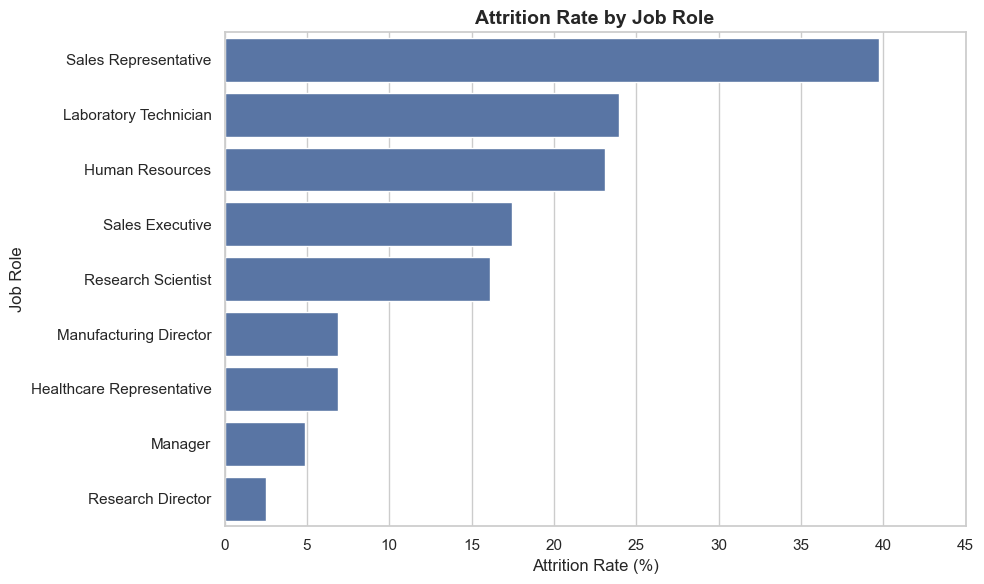

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=jobrole_attrition.reset_index(),
    x="Attrition_Rate",
    y="JobRole",
    color="#4C72B0"
)

plt.title("Attrition Rate by Job Role", fontsize=14, fontweight="bold")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.xlim(0, 45)

plt.tight_layout()
plt.savefig("../visuals/attrition_by_job_role.png", dpi=300)
plt.show()

In [50]:
agegroup_attrition_ordered = agegroup_attrition.reindex(age_labels)

agegroup_attrition_ordered

,Total_Employees,Attrition_Count,Attrition_Rate
AgeGroup,,,
18-25,123,44,35.77
26-35,606,116,19.14
36-45,468,43,9.19
46-55,226,26,11.50
56-65,47,8,17.02


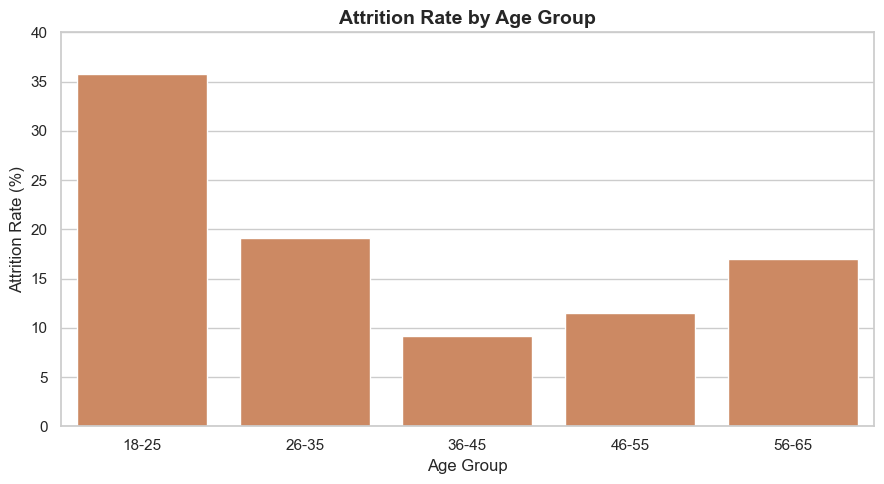

In [54]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=agegroup_attrition_ordered.reset_index(),
    x="AgeGroup",
    y="Attrition_Rate",
    color="#DD8452"
)

plt.title("Attrition Rate by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 40)

plt.tight_layout()
plt.savefig("../visuals/attrition_by_age_group.png", dpi=300)
plt.show()

## 7. Compensation and Tenure Analysis

In [55]:
income_by_attrition = (
    df_clean.groupby("Attrition")
    .agg(
        Employee_Count=("EmployeeNumber", "count"),
        Average_Monthly_Income=("MonthlyIncome", "mean"),
        Median_Monthly_Income=("MonthlyIncome", "median")
    )
    .round(2)
)

income_by_attrition

,Employee_Count,Average_Monthly_Income,Median_Monthly_Income
Attrition,,,
No,1233,6832.74,5204.0
Yes,237,4787.09,3202.0


In [56]:
income_bins = [0, 3000, 6000, 10000, float("inf")]

income_labels = [
    "Below 3K",
    "3K-6K",
    "6K-10K",
    "Above 10K"
]

df_clean["IncomeGroup"] = pd.cut(
    df_clean["MonthlyIncome"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

incomegroup_attrition = calculate_attrition_rate(df_clean, "IncomeGroup")
incomegroup_attrition

,Total_Employees,Attrition_Count,Attrition_Rate
IncomeGroup,,,
Below 3K,395,113,28.61
3K-6K,519,66,12.72
6K-10K,275,33,12.00
Above 10K,281,25,8.90


In [57]:
tenure_bins = [-1, 1, 5, 10, float("inf")]

tenure_labels = [
    "0-1 Years",
    "2-5 Years",
    "6-10 Years",
    "11+ Years"
]

df_clean["TenureGroup"] = pd.cut(
    df_clean["YearsAtCompany"],
    bins=tenure_bins,
    labels=tenure_labels
)

tenure_attrition = calculate_attrition_rate(df_clean, "TenureGroup")
tenure_attrition

,Total_Employees,Attrition_Count,Attrition_Rate
TenureGroup,,,
0-1 Years,215,75,34.88
2-5 Years,561,87,15.51
6-10 Years,448,55,12.28
11+ Years,246,20,8.13


### Grouping Method

Monthly income and years at company were converted into business-friendly groups to make attrition patterns easier to compare.

### Compensation and Tenure Insights

- Attrition is highest among employees with 0–1 years at the company, at 34.88%.
- Employees earning below 3K have an attrition rate of 28.61%.
- Employees who left had lower average and median monthly income than employees who stayed.
- Income and tenure are associated with attrition, but further analysis is needed before treating either as a direct cause.

In [59]:
income_attrition_ordered = incomegroup_attrition.reindex(income_labels)
tenure_attrition_ordered = tenure_attrition.reindex(tenure_labels)

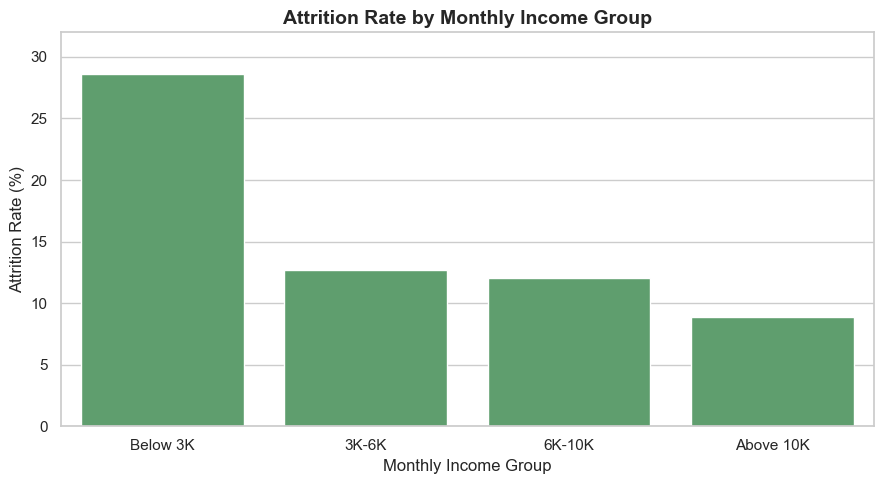

In [60]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=income_attrition_ordered.reset_index(),
    x="IncomeGroup",
    y="Attrition_Rate",
    color="#55A868"
)

plt.title("Attrition Rate by Monthly Income Group", fontsize=14, fontweight="bold")
plt.xlabel("Monthly Income Group")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 32)

plt.tight_layout()
plt.savefig("../visuals/attrition_by_income_group.png", dpi=300)
plt.show()

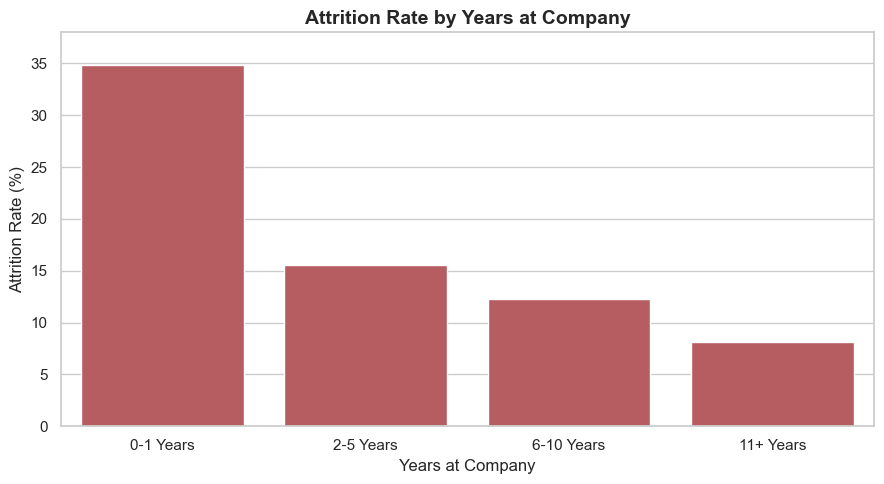

In [61]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_attrition_ordered.reset_index(),
    x="TenureGroup",
    y="Attrition_Rate",
    color="#C44E52"
)

plt.title("Attrition Rate by Years at Company", fontsize=14, fontweight="bold")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 38)

plt.tight_layout()
plt.savefig("../visuals/attrition_by_tenure_group.png", dpi=300)
plt.show()

## 8. Employee Experience Analysis

In [62]:
satisfaction_labels = {
    1: "1 - Low",
    2: "2 - Medium",
    3: "3 - High",
    4: "4 - Very High"
}

worklife_labels = {
    1: "1 - Bad",
    2: "2 - Good",
    3: "3 - Better",
    4: "4 - Best"
}

df_clean["JobSatisfactionLabel"] = df_clean["JobSatisfaction"].map(
    satisfaction_labels
)

df_clean["EnvironmentSatisfactionLabel"] = df_clean[
    "EnvironmentSatisfaction"
].map(satisfaction_labels)

df_clean["JobInvolvementLabel"] = df_clean["JobInvolvement"].map(
    satisfaction_labels
)

df_clean["WorkLifeBalanceLabel"] = df_clean["WorkLifeBalance"].map(
    worklife_labels
)

In [63]:
job_satisfaction_attrition = calculate_attrition_rate(
    df_clean,
    "JobSatisfactionLabel"
)

worklife_attrition = calculate_attrition_rate(
    df_clean,
    "WorkLifeBalanceLabel"
)

job_satisfaction_attrition, worklife_attrition

(                      Total_Employees  Attrition_Count  Attrition_Rate
 JobSatisfactionLabel                                                  
 1 - Low                           289               66           22.84
 3 - High                          442               73           16.52
 2 - Medium                        280               46           16.43
 4 - Very High                     459               52           11.33,
                       Total_Employees  Attrition_Count  Attrition_Rate
 WorkLifeBalanceLabel                                                  
 1 - Bad                            80               25           31.25
 4 - Best                          153               27           17.65
 2 - Good                          344               58           16.86
 3 - Better                        893              127           14.22)

In [64]:
environment_attrition = calculate_attrition_rate(
    df_clean,
    "EnvironmentSatisfactionLabel"
)

involvement_attrition = calculate_attrition_rate(
    df_clean,
    "JobInvolvementLabel"
)

environment_attrition, involvement_attrition

(                              Total_Employees  Attrition_Count  Attrition_Rate
 EnvironmentSatisfactionLabel                                                  
 1 - Low                                   284               72           25.35
 2 - Medium                                287               43           14.98
 3 - High                                  453               62           13.69
 4 - Very High                             446               60           13.45,
                      Total_Employees  Attrition_Count  Attrition_Rate
 JobInvolvementLabel                                                  
 1 - Low                           83               28           33.73
 2 - Medium                       375               71           18.93
 3 - High                         868              125           14.40
 4 - Very High                    144               13            9.03)

### Employee Experience Insights

- Low job involvement is strongly associated with attrition: 33.73% versus 9.03% among employees with very high involvement.
- Employees reporting bad work-life balance have a 31.25% attrition rate.
- Low environment satisfaction and low job satisfaction are also associated with higher attrition.
- These results are associations from a cross-sectional dataset, not proof of causation.

In [66]:
satisfaction_order = list(satisfaction_labels.values())
worklife_order = list(worklife_labels.values())

job_satisfaction_ordered = job_satisfaction_attrition.reindex(
    satisfaction_order
)

environment_ordered = environment_attrition.reindex(
    satisfaction_order
)

involvement_ordered = involvement_attrition.reindex(
    satisfaction_order
)

worklife_ordered = worklife_attrition.reindex(
    worklife_order
)

In [77]:
def plot_attrition_bar(summary, group_column, title, filename, color):
    plt.figure(figsize=(9, 5))
    
    sns.barplot(
        data=summary.reset_index(),
        x=group_column,
        y="Attrition_Rate",
        color=color
    )
    
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("Attrition Rate (%)")
    plt.ylim(0, 38)
    
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=300)
    plt.show()

In [75]:
from pathlib import Path

def plot_attrition_bar(summary, group_column, title, filename, color):
    output_dir = Path(
        r"C:\Users\janakiram\Documents\Data_Analytics_Portfolio"
        r"\PROJECTS\HR-Employee-Attrition-Project\visuals"
    )
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    plt.figure(figsize=(9, 5))
    
    sns.barplot(
        data=summary.reset_index(),
        x=group_column,
        y="Attrition_Rate",
        color=color
    )
    
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("Attrition Rate (%)")
    plt.ylim(0, 38)
    
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=300)
    plt.show()

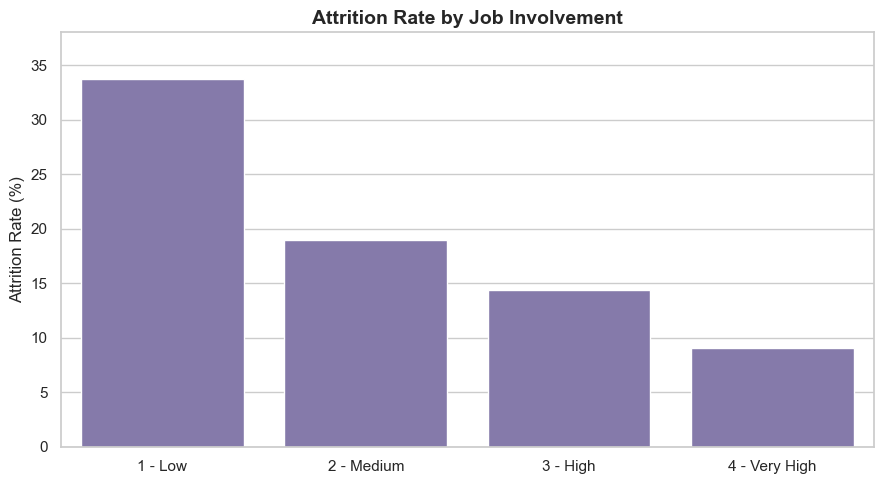

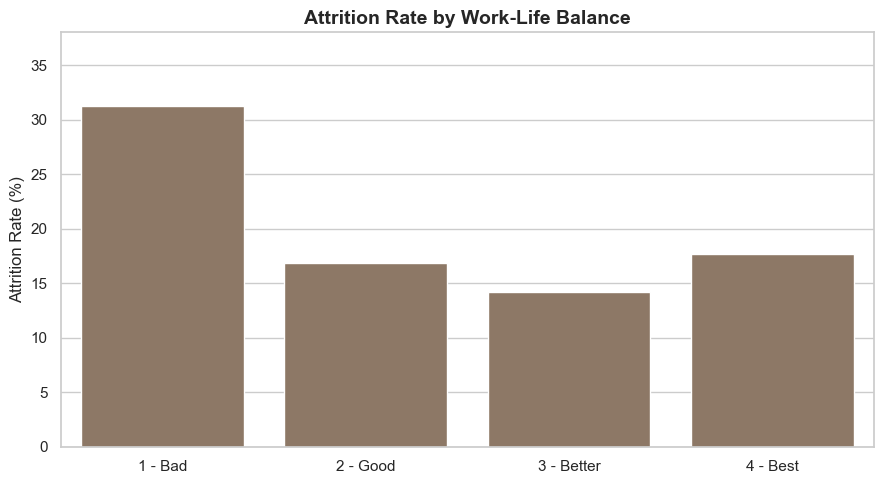

In [76]:
plot_attrition_bar(
    involvement_ordered,
    "JobInvolvementLabel",
    "Attrition Rate by Job Involvement",
    "attrition_by_job_involvement.png",
    "#8172B2"
)

plot_attrition_bar(
    worklife_ordered,
    "WorkLifeBalanceLabel",
    "Attrition Rate by Work-Life Balance",
    "attrition_by_worklife_balance.png",
    "#937860"
)

## 9. Combined Risk Analysis

In [79]:
age_overtime_attrition = (
    df_clean.groupby(
        ["AgeGroup", "OverTime"],
        observed=False
    )
    .agg(
        Total_Employees=("AttritionFlag", "count"),
        Attrition_Count=("AttritionFlag", "sum"),
        Attrition_Rate=("AttritionFlag", "mean")
    )
)

age_overtime_attrition["Attrition_Rate"] = (
    age_overtime_attrition["Attrition_Rate"] * 100
).round(2)

age_overtime_attrition = age_overtime_attrition.sort_values(
    "Attrition_Rate",
    ascending=False
)

age_overtime_attrition

,,Total_Employees,Attrition_Count,Attrition_Rate
AgeGroup,OverTime,,,
18-25,Yes,39,25,64.10
26-35,Yes,159,62,38.99
56-65,Yes,17,4,23.53
18-25,No,84,19,22.62
46-55,Yes,66,13,19.70
36-45,Yes,135,23,17.04
56-65,No,30,4,13.33
26-35,No,447,54,12.08
46-55,No,160,13,8.12


In [80]:
age_overtime_pivot = age_overtime_attrition["Attrition_Rate"].unstack()

age_overtime_pivot = age_overtime_pivot.reindex(
    index=age_labels,
    columns=["No", "Yes"]
)

age_overtime_pivot

OverTime,No,Yes
AgeGroup,,
18-25,22.62,64.10
26-35,12.08,38.99
36-45,6.01,17.04
46-55,8.12,19.70
56-65,13.33,23.53


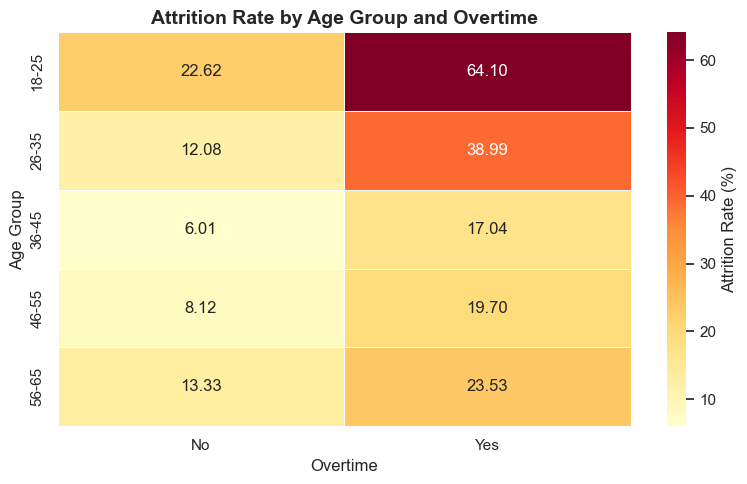

In [81]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    age_overtime_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Attrition Rate (%)"}
)

plt.title(
    "Attrition Rate by Age Group and Overtime",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Overtime")
plt.ylabel("Age Group")

plt.tight_layout()

plt.savefig(
    r"C:\Users\janakiram\Documents\Data_Analytics_Portfolio"
    r"\PROJECTS\HR-Employee-Attrition-Project\visuals"
    r"\attrition_age_overtime_heatmap.png",
    dpi=300
)

plt.show()

In [82]:
overtime_age_details = (
    age_overtime_attrition
    .reset_index()
    .query("OverTime == 'Yes'")
    .sort_values("Attrition_Rate", ascending=False)
)

overtime_age_details

,AgeGroup,OverTime,Total_Employees,Attrition_Count,Attrition_Rate
0,18-25,Yes,39,25,64.10
1,26-35,Yes,159,62,38.99
2,56-65,Yes,17,4,23.53
4,46-55,Yes,66,13,19.70
5,36-45,Yes,135,23,17.04


### Combined Risk Insight

The highest-risk segment is employees aged 18–25 who work overtime, with a 64.10% attrition rate (25 of 39 employees). Employees aged 26–35 who work overtime also have high attrition at 38.99% (62 of 159 employees).

HR should prioritize a closer review of workload, onboarding, manager support, compensation, and career development for early-career employees working overtime.

In [83]:
from pathlib import Path

cleaned_file_path = Path(
    r"C:\Users\janakiram\Documents\Data_Analytics_Portfolio"
    r"\PROJECTS\HR-Employee-Attrition-Project\data"
    r"\HR_Employee_Attrition_Cleaned.csv"
)

cleaned_file_path.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset saved to:")
print(cleaned_file_path)
print("\nSaved dataset shape:", df_clean.shape)

Cleaned dataset saved to:
C:\Users\janakiram\Documents\Data_Analytics_Portfolio\PROJECTS\HR-Employee-Attrition-Project\data\HR_Employee_Attrition_Cleaned.csv

Saved dataset shape: (1470, 40)


In [84]:
saved_df = pd.read_csv(cleaned_file_path)

print(saved_df.shape)
saved_df.head()

(1470, 40)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag,AgeGroup,IncomeGroup,TenureGroup,JobSatisfactionLabel,EnvironmentSatisfactionLabel,JobInvolvementLabel,WorkLifeBalanceLabel
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,1,36-45,3K-6K,6-10 Years,4 - Very High,2 - Medium,3 - High,1 - Bad
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,0,46-55,3K-6K,6-10 Years,2 - Medium,3 - High,2 - Medium,3 - Better
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,1,36-45,Below 3K,0-1 Years,3 - High,4 - Very High,2 - Medium,3 - Better
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,0,26-35,Below 3K,6-10 Years,3 - High,4 - Very High,3 - High,3 - Better
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,0,26-35,3K-6K,2-5 Years,2 - Medium,1 - Low,3 - High,3 - Better
